# 0. Importing libraries

In [1]:
import torch
from torch import nn # nn contains all of PyTorch's building blocks for neural networks

import numpy as np
import matplotlib.pyplot as plt

In [2]:
print('Check version: ', torch.__version__)
print('Check cuda: ', torch.cuda.is_available())

Check version:  2.6.0+cu124
Check cuda:  False


📔 Slide

# 1. Preparing Data

**Create dataset**

x (data/feature)

In [3]:
start = 0
end = 1
step = 0.02
x = torch.arange(start, end, step)

print(x, x.shape)

tensor([0.0000, 0.0200, 0.0400, 0.0600, 0.0800, 0.1000, 0.1200, 0.1400, 0.1600,
        0.1800, 0.2000, 0.2200, 0.2400, 0.2600, 0.2800, 0.3000, 0.3200, 0.3400,
        0.3600, 0.3800, 0.4000, 0.4200, 0.4400, 0.4600, 0.4800, 0.5000, 0.5200,
        0.5400, 0.5600, 0.5800, 0.6000, 0.6200, 0.6400, 0.6600, 0.6800, 0.7000,
        0.7200, 0.7400, 0.7600, 0.7800, 0.8000, 0.8200, 0.8400, 0.8600, 0.8800,
        0.9000, 0.9200, 0.9400, 0.9600, 0.9800]) torch.Size([50])


In [4]:
x = x.unsqueeze(dim=1)
print(x.shape)

torch.Size([50, 1])


y (label)

In [5]:
weight = np.random.random()
bias = np.random.random()

print(f'Weight value: {weight:.4f}')
print(f'Bias value: {bias:.4f}')

y = weight * x + bias

Weight value: 0.4350
Bias value: 0.7169


In [6]:
print('x (data):\n', x[:5], x.shape)
print()
print('y (label):\n', y[:5], y.shape)

x (data):
 tensor([[0.0000],
        [0.0200],
        [0.0400],
        [0.0600],
        [0.0800]]) torch.Size([50, 1])

y (label):
 tensor([[0.7169],
        [0.7256],
        [0.7343],
        [0.7430],
        [0.7517]]) torch.Size([50, 1])


**Split data into training and test sets**

In [7]:
train_percent = 0.8 # 80% of data used for training set, 20% for testing
train_split = int(train_percent * len(x))
print(f'Length x: {len(x)}, train_split: {train_split}')

Length x: 50, train_split: 40


In [8]:
x_train, y_train = x[:train_split], y[:train_split]

In [9]:
print(f'Length x train: {len(x_train)} | Length y train: {len(y_train)}')

Length x train: 40 | Length y train: 40


In [10]:
x_test, y_test = x[train_split:], y[train_split:]

In [11]:
print(f'Length x test: {len(x_test)} | Length y test: {len(y_test)}')

Length x test: 10 | Length y test: 10


defining visualization function

In [12]:
def plot_predictions(predictions=None, show_difference=None):

    plt.scatter(x_train, y_train, c="b", s=4, label="Training data") # train
    plt.scatter(x_test, y_test, c="g", s=4, label="Testing data") # test

    if predictions is not None:
        plt.scatter(x_test, predictions, c="r", s=4, label="Predictions") # prediction

    # Draw lines between the predictions and actual values
    if show_difference:
        for i in range(len(x_test)):
            plt.plot([x_test[i], x_test[i]], [y_test[i], predictions[i]], c='orange', lw=0.5)

    plt.legend()

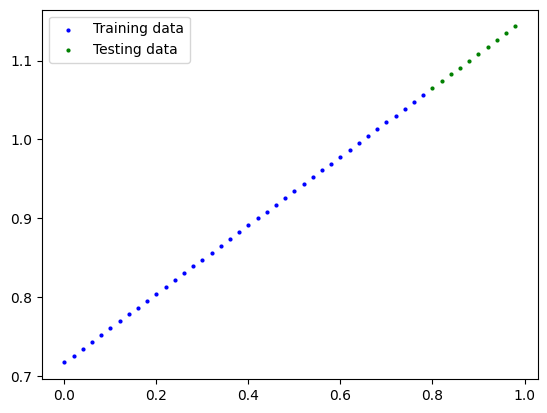

In [13]:
plot_predictions()

# 2. Building the Model

**Linear Regression:**

📔 Slide

In [14]:
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.weight = nn.Parameter(
            torch.randn(1, dtype=torch.float),
            requires_grad=True)

        self.bias = nn.Parameter(
            torch.randn(1, dtype=torch.float),
            requires_grad=True)

    def forward(self, x: torch.Tensor):
        return self.weight * x + self.bias

**PyTorch model**

In [15]:
seed = 123
torch.manual_seed(seed) # Set manual seed since nn.Parameter are randomly initialzied

model = LinearRegressionModel()

list(model.parameters()) # Check the nn.Parameter(s) within the nn.Module subclass we created

[Parameter containing:
 tensor([-0.1115], requires_grad=True),
 Parameter containing:
 tensor([0.1204], requires_grad=True)]

In [16]:
# List named parameters (what the model contains).
model.state_dict()

OrderedDict([('weight', tensor([-0.1115])), ('bias', tensor([0.1204]))])

In [17]:
original_weight, original_bias = model.weight.item(), model.bias.item() # for later

📔 Slide

In [18]:
# Make predictions with model

with torch.inference_mode(): # Locally disabling gradient computation
# with torch.no_grad():
    y_preds = model(x_test)

In [19]:
print(f"Number of testing samples: {len(x_test)}")
print(f"Number of predictions made: {len(y_preds)}")
print(f"\nPredicted values:\n{y_preds}")

Number of testing samples: 10
Number of predictions made: 10

Predicted values:
tensor([[0.0312],
        [0.0290],
        [0.0267],
        [0.0245],
        [0.0223],
        [0.0200],
        [0.0178],
        [0.0156],
        [0.0134],
        [0.0111]])


visualize

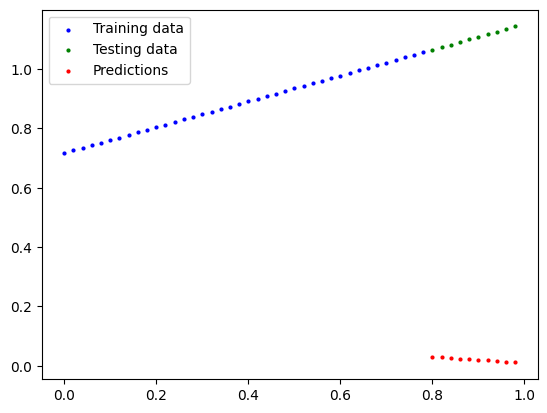

In [20]:
plot_predictions(predictions=y_preds)

difference:

In [21]:
y_test - y_preds

tensor([[1.0337],
        [1.0447],
        [1.0556],
        [1.0665],
        [1.0775],
        [1.0884],
        [1.0993],
        [1.1103],
        [1.1212],
        [1.1321]])

alternative way:

In [22]:
L1Loss = nn.L1Loss(reduction='none')
L1Loss(y_test, y_preds)

tensor([[1.0337],
        [1.0447],
        [1.0556],
        [1.0665],
        [1.0775],
        [1.0884],
        [1.0993],
        [1.1103],
        [1.1212],
        [1.1321]])

In [23]:
L1Loss = nn.L1Loss(reduction='mean')
L1Loss(y_test, y_preds)

tensor(1.0829)

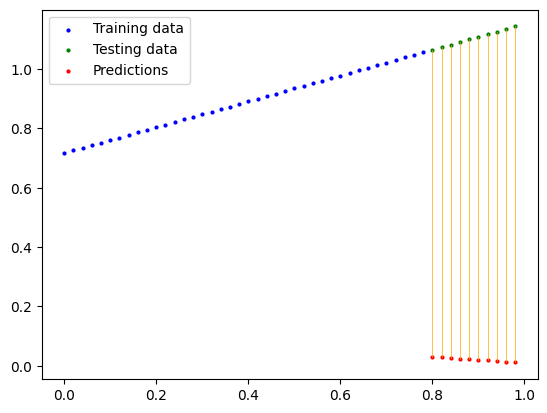

In [24]:
plot_predictions(predictions=y_preds, show_difference=True)

# 3. Training the model

**Define loss function and optimizer**

In [25]:
loss_function = nn.L1Loss() # MAE loss is same as L1Loss

In [26]:
optimizer = torch.optim.SGD(
    params=model.parameters(), # parameters of target model to optimize
    lr=0.01 # learning rate (how much the optimizer should change parameters at each step, higher=more (less stable), lower=less (might take a long time)
    )

**Creating an optimization loop in PyTorch**

In [27]:
epochs = 200 # how many times the model will pass over the training data

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []

for epoch in range(1, epochs + 1):

    ### Training

    # Put model in training mode (default)
    model.train()

    # 1. Forward pass on train data using the forward() method inside
    y_pred = model(x_train)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_function(y_pred, y_train)

    # 3. Zero grad of the optimizer (Reset gradients for next iteration)
    optimizer.zero_grad()

    # 4. Loss backwards (Compute gradients of loss w.r.t. each parameter)
    loss.backward()

    # 5. Progress the optimizer (Update parameters using gradients)
    optimizer.step()

    ### Testing

    # Put the model in evaluation mode
    model.eval()

    with torch.inference_mode():
      # 1. Forward pass on test data
      test_preds = model(x_test)

      # 2. Caculate loss on test data
      test_loss = loss_function(test_preds, y_test)

      # Print out what's happening
      if epoch % 5 == 0:
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | Train Loss: {loss:.4f} | Test Loss: {test_loss:.4f} ")

Epoch: 5 | Train Loss: 0.7636 | Test Loss: 1.0156 
Epoch: 10 | Train Loss: 0.7060 | Test Loss: 0.9482 
Epoch: 15 | Train Loss: 0.6484 | Test Loss: 0.8809 
Epoch: 20 | Train Loss: 0.5908 | Test Loss: 0.8135 
Epoch: 25 | Train Loss: 0.5332 | Test Loss: 0.7462 
Epoch: 30 | Train Loss: 0.4756 | Test Loss: 0.6788 
Epoch: 35 | Train Loss: 0.4180 | Test Loss: 0.6114 
Epoch: 40 | Train Loss: 0.3604 | Test Loss: 0.5441 
Epoch: 45 | Train Loss: 0.3028 | Test Loss: 0.4767 
Epoch: 50 | Train Loss: 0.2452 | Test Loss: 0.4094 
Epoch: 55 | Train Loss: 0.1876 | Test Loss: 0.3420 
Epoch: 60 | Train Loss: 0.1300 | Test Loss: 0.2747 
Epoch: 65 | Train Loss: 0.0856 | Test Loss: 0.2177 
Epoch: 70 | Train Loss: 0.0648 | Test Loss: 0.1774 
Epoch: 75 | Train Loss: 0.0553 | Test Loss: 0.1503 
Epoch: 80 | Train Loss: 0.0507 | Test Loss: 0.1322 
Epoch: 85 | Train Loss: 0.0480 | Test Loss: 0.1199 
Epoch: 90 | Train Loss: 0.0460 | Test Loss: 0.1110 
Epoch: 95 | Train Loss: 0.0442 | Test Loss: 0.1055 
Epoch: 100 | 

Plot the loss curves

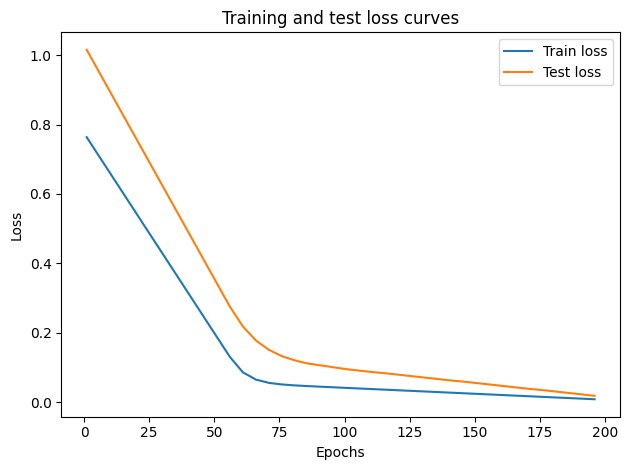

In [28]:
epoch_counts = list(range(1, 200+1, 5))

plt.plot(epoch_counts, train_loss_values, label="Train loss")
plt.plot(epoch_counts, test_loss_values, label="Test loss")

plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()

plt.tight_layout()
plt.show()

In [29]:
# Find our model's learned parameters
print("Model learned:")
print(model.state_dict())
print()
print(f"Original weight: {original_weight:.4f}, Original bias: {original_bias:.4f}")

Model learned:
OrderedDict([('weight', tensor([0.3963])), ('bias', tensor([0.7334]))])

Original weight: -0.1115, Original bias: 0.1204


Visualize the results

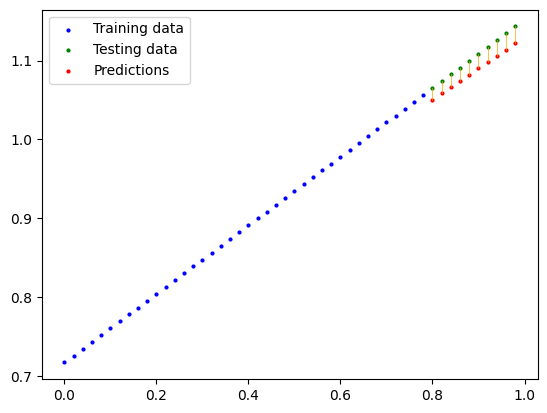

In [30]:
plot_predictions(predictions=test_preds, show_difference=True)

# 4. Saving the model's weight parameters

In [31]:
import os
save_path = './saves'
os.makedirs(save_path, exist_ok=True)

In [32]:
# @title
torch.save(model.state_dict(), # only saving the state_dict() only saves the models learned parameters
           save_path + '/weights' + '.pth')

# 5. Loading a saved PyTorch model's `state_dict()`

In [33]:
new_model = LinearRegressionModel()

load_path = save_path + '/weights' + '.pth'

new_model.load_state_dict(torch.load(load_path))

<All keys matched successfully>

In [34]:
new_model.eval()

LinearRegressionModel()

In [35]:
with torch.inference_mode():
    new_model_preds = new_model(x_test)

In [36]:
# Compare previous model predictions with loaded model predictions (these should be the same)
test_preds == new_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

# 6. Combining all the pieces

import

In [62]:
import torch
from torch import nn
import numpy as np
from sklearn.model_selection import train_test_split

data

In [63]:
# x
x = torch.arange(0, 1, 0.02).unsqueeze(1)

# y
weight = np.random.random()
bias = np.random.random()
y = weight * x + bias

# Split data
train_percent = 0.8

x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=train_percent, random_state=156)


# Without this, error will happen (not all model/data on device)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

x_train, x_test = x_train.to(device), x_test.to(device)
y_train, y_test = y_train.to(device), y_test.to(device)

print(f"x_train: {len(x_train)}, y_train: {len(y_train)}")
print(f"x_test: {len(x_test)}, y_test: {len(y_test)}")

x_train: 40, y_train: 40
x_test: 10, y_test: 10


Model

📔 Slide

In [64]:
class LinearRegressionModel_V2(nn.Module):
    def __init__(self):
        super().__init__()

        self.linear_layer = nn.Linear(in_features=1, out_features=1)

    def forward(self, x: torch.Tensor):
        return self.linear_layer(x)

In [65]:
linear_model = LinearRegressionModel_V2().to(device)

In [66]:
linear_model

LinearRegressionModel_V2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [67]:
linear_model.state_dict()

OrderedDict([('linear_layer.weight', tensor([[-0.5845]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.2681], device='cuda:0'))])

Loss function & optimizer

In [68]:
criterion = nn.L1Loss()

optimizer = torch.optim.SGD(params=linear_model.parameters(), lr=0.005)

Training

In [69]:
epochs = 1000

for epoch in range(1, epochs+1):

    # 1. Forward pass
    y_pred = linear_model(x_train)

    # 2. Calculate loss
    loss = criterion(y_pred, y_train)

    # 3. Zero grad optimizer
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Step the optimizer
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Train loss: {loss:.4f}")

Epoch: 100 | Train loss: 0.7033
Epoch: 200 | Train loss: 0.3155
Epoch: 300 | Train loss: 0.2112
Epoch: 400 | Train loss: 0.1823
Epoch: 500 | Train loss: 0.1577
Epoch: 600 | Train loss: 0.1331
Epoch: 700 | Train loss: 0.1086
Epoch: 800 | Train loss: 0.0841
Epoch: 900 | Train loss: 0.0596
Epoch: 1000 | Train loss: 0.0351


testing (evaluating)

In [70]:
linear_model.eval() # put the model in evaluation mode for testing (inference)

for epoch in range(5):

    # 1. Forward pass
    with torch.inference_mode():
        test_preds = linear_model(x_test)

        # 2. Calculate the loss
        test_loss = criterion(test_preds, y_test)

        print(f"Test loss: {test_loss:.4f}")

Test loss: 0.0362
Test loss: 0.0362
Test loss: 0.0362
Test loss: 0.0362
Test loss: 0.0362


defining visualization function

In [71]:
def plot_predictions(predictions=None):
    # Ensure all tensors are on the CPU device for plotting
    x_train_np = x_train.cpu().numpy()
    y_train_np = y_train.cpu().numpy()
    x_test_np = x_test.cpu().numpy()
    y_test_np = y_test.cpu().numpy()

    plt.scatter(x_train_np, y_train_np, c="b", s=4, label="Training data")  # train
    plt.scatter(x_test_np, y_test_np, c="g", s=4, label="Testing data")  # test

    if predictions is not None:
        predictions_np = predictions.cpu().detach().numpy()
        plt.scatter(x_test_np, predictions_np, c="r", s=4, label="Predictions")  # prediction

    # plt.yticks(np.arange(0.038, 0.07, 0.003))
    plt.legend()
    plt.show()

In [72]:
import matplotlib.pyplot as plt

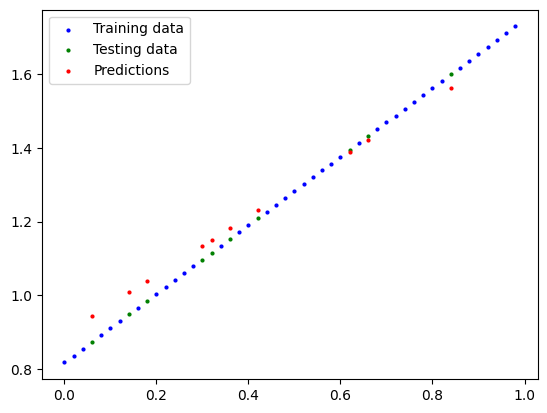

In [73]:
plot_predictions(predictions=test_preds)

save weights

In [75]:
import os
save_path = './saves'
os.makedirs(save_path, exist_ok=True)

torch.save(linear_model.state_dict(), # only saving the state_dict() only saves the models learned parameters
           save_path + '/linear_model_weights' + '.pth')

📔 Slide